# Лабораторная работа №1. Линейная регрессия и факторный анализ
### Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество

### Описание датасета 
diamonds.csv - содержит информацию о характеристиках и ценах на бриллианты.   
Датасет содержит 53 940 строк и 10 признаков столбцов  
Столбцы в датасете:  
`carat` - вес брилллианта  
`cut` - качество огранки  
`color` - цвет бриллианта  
`clarity` - чистота бриллианта   
`depth` - общая глубина  
`table` -  ширина верхней площадки относительно самой широкой точки  
`x` - длина в мм  
`y` - ширина в мм  
`z`  - глубина в мм  
Целевая переменная - `price` - цена бриллианта в долларах.

### Импорты библиотек

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Первичный анализ

Загрузка датасета

In [42]:
df = pd.read_csv('diamonds.csv')
print("Размер датасета:", df.shape)
display(df.head())


Размер датасета: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [44]:
# Общая информация о данных
print("\nИнформация о датасете:")
display(df.info())

print("\nОписательная статистика числовых признаков:")
display(df.describe().T)



Информация о датасете:
<class 'pandas.DataFrame'>
Index: 53920 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53920 non-null  float64
 1   cut      53920 non-null  str    
 2   color    53920 non-null  str    
 3   clarity  53920 non-null  str    
 4   depth    53920 non-null  float64
 5   table    53920 non-null  float64
 6   price    53920 non-null  int64  
 7   x        53920 non-null  float64
 8   y        53920 non-null  float64
 9   z        53920 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.5 MB


None


Описательная статистика числовых признаков:


,count,mean,std,min,25%,50%,75%,max
carat,53920.0,0.797698,0.473795,0.20,0.40,0.70,1.04,5.01
depth,53920.0,61.749514,1.432331,43.00,61.00,61.80,62.50,79.00
table,53920.0,57.456834,2.234064,43.00,56.00,57.00,59.00,95.00
price,53920.0,3930.993231,3987.280446,326.00,949.00,2401.00,5323.25,18823.00
x,53920.0,5.731627,1.119423,3.73,4.71,5.70,6.54,10.74
y,53920.0,5.734887,1.140126,3.68,4.72,5.71,6.54,58.90
z,53920.0,3.540046,0.702530,1.07,2.91,3.53,4.04,31.80


Проверка пропусков 

In [22]:
print("Количество пропусков:")
print(df.isnull().sum())

Количество пропусков:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [23]:
zero_dimensions = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f"\nКоличество строк с нулевыми размерами алмазов (x, y, z): {len(zero_dimensions)}")

df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"Размер датасета после удаления аномалий: {df.shape}")



Количество строк с нулевыми размерами алмазов (x, y, z): 20
Размер датасета после удаления аномалий: (53920, 10)


### Визуализация распределений и кодирование признаков

Целевая переменная 

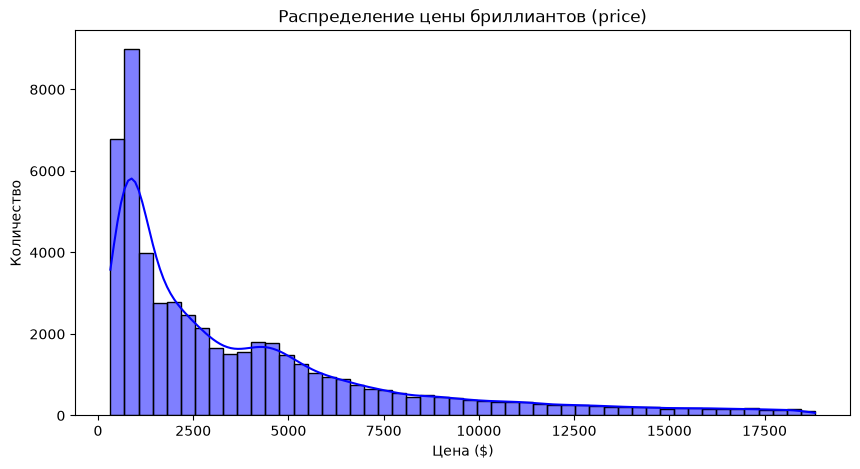

In [45]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Распределение цены бриллиантов (price)')
plt.xlabel('Цена ($)')
plt.ylabel('Количество')
plt.show()

Визуализация распределения числовых признаков

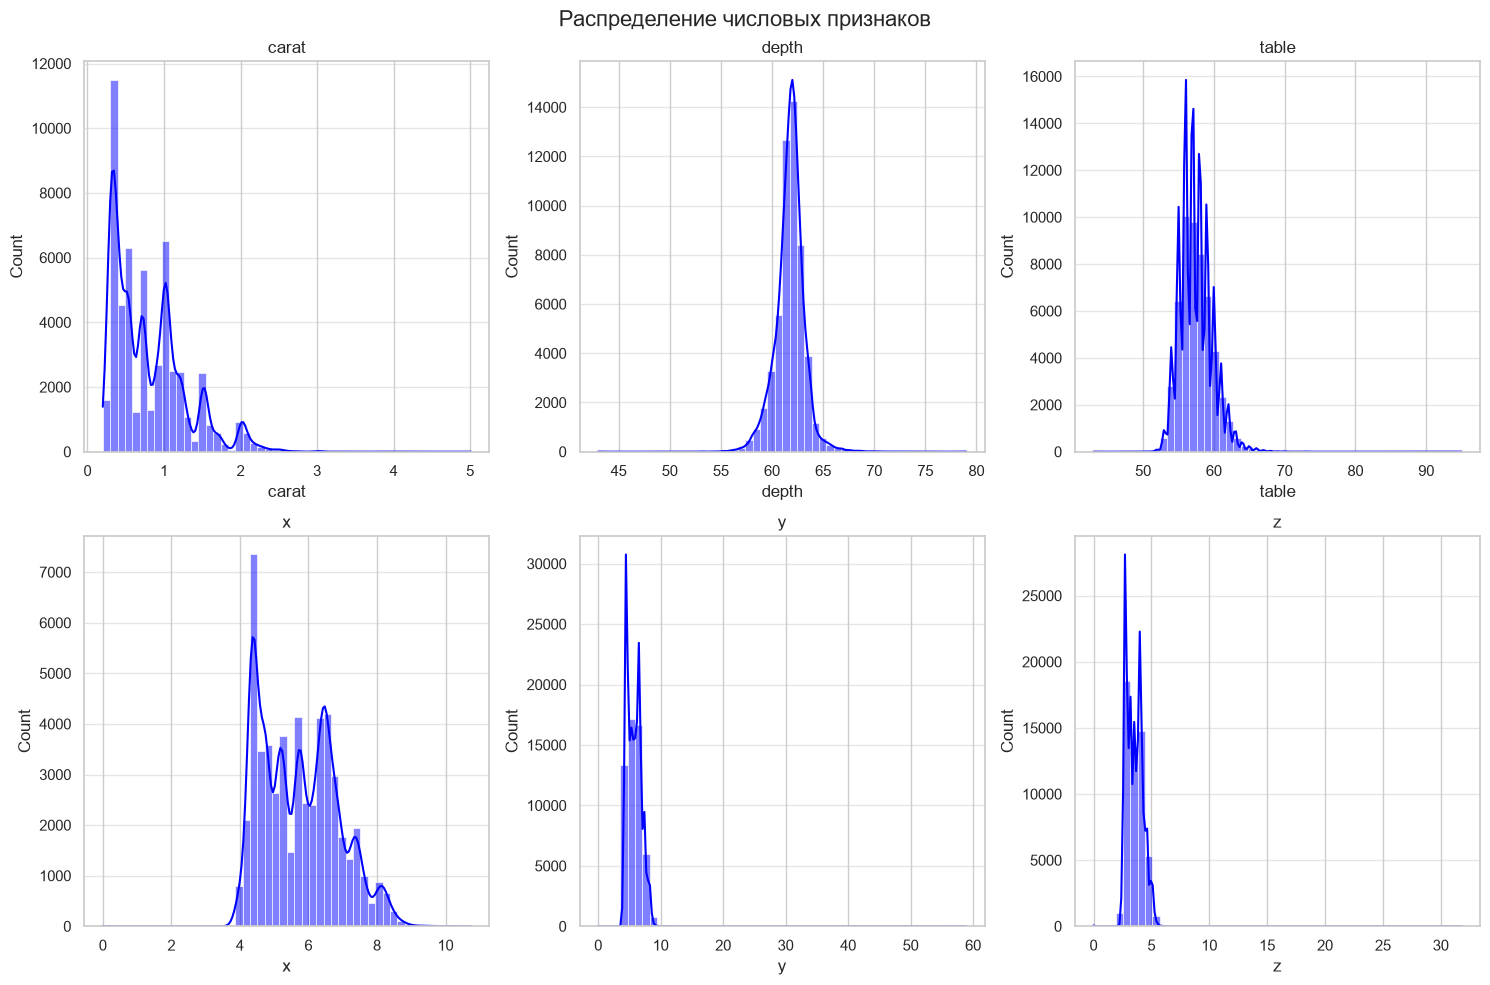

In [92]:
numeric_features = ['carat', 'depth', 'table', 'x', 'y', 'z']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16)

for i, col in enumerate(numeric_features):
    ax = axes[i//3, i%3]
    sns.histplot(df[col], bins=50, kde=True, color='blue', ax=ax)
    ax.set_title(col)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

Визуализация категориальных признаков

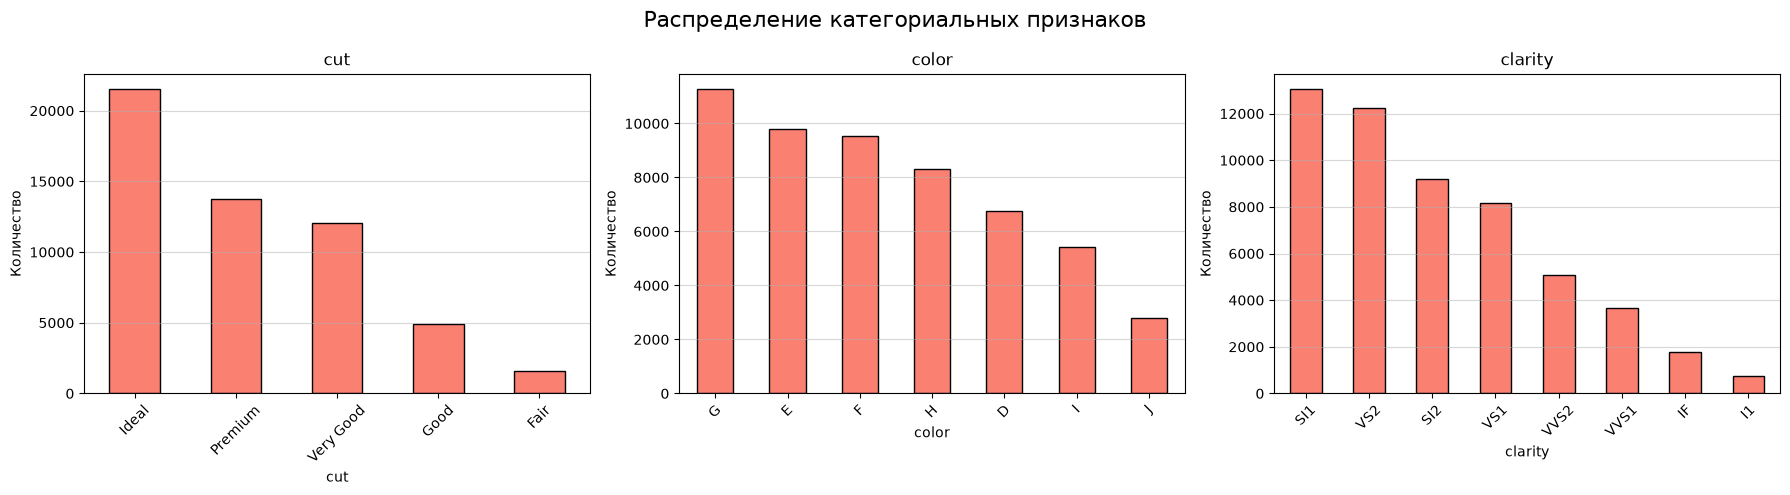

In [47]:
categorical_features = ['cut', 'color', 'clarity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение категориальных признаков', fontsize=16)

for i, col in enumerate(categorical_features):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Количество')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

Кодирование категориальных признаков 

In [49]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
df['cut'] = le.fit_transform(df['cut'])
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])

display(df.head())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


Корреляционный анализ и проверка на мультиколлинеарность

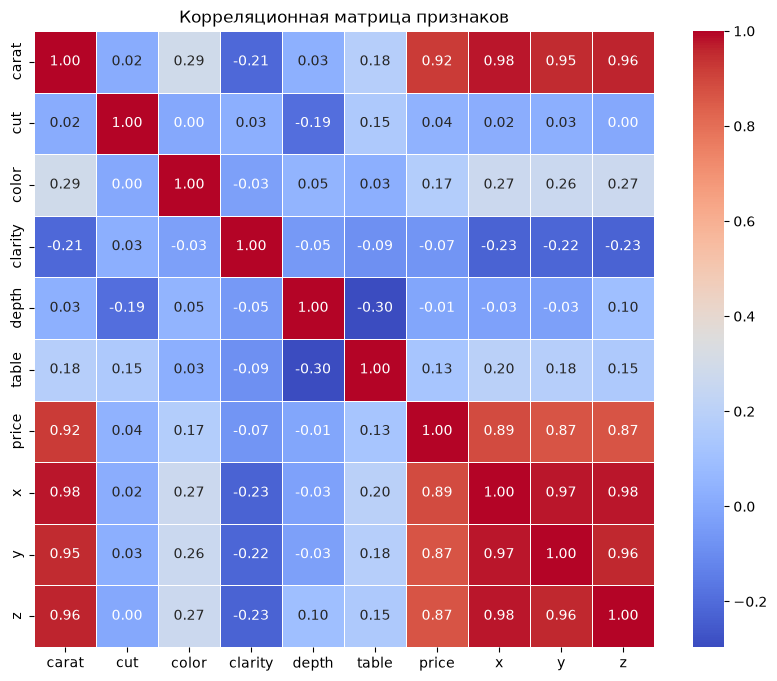

In [50]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

Анализ матрицы корреляций показывает высокую мультиколлинеарность между геометрическими размерами бриллианта (x, y, z) и его массой (carat), коэффициенты корреляции между которыми превышают 0.95.

Расчет VIF для выявления мультиколлинеарности

In [51]:
X_vif = df.drop('price', axis=1)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("Коэффициенты VIF (Variance Inflation Factor):")
display(vif_data.sort_values(by="VIF", ascending=False))

Коэффициенты VIF (Variance Inflation Factor):


,Feature,VIF
6,x,63.890788
8,z,29.935398
0,carat,24.777952
7,y,20.731517
4,depth,1.630528
5,table,1.160545
2,color,1.100392
3,clarity,1.067282
1,cut,1.052230


Высокие значения VIF у признаков `x`, `y`, `z` и `carat` говорят о сильной мультиколлинеарности. Это логично, так как вес бриллианта напрямую зависит от его геометрических размеров.

Построение регрессионных моделей

In [64]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    
    return {"Model": model_name, "RMSE": rmse, "R²": r2, "MAPE": mape}

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

results_before_pca = []

for name, model in models.items():
    res = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    results_before_pca.append(res)

df_results_before = pd.DataFrame(results_before_pca)
print("Результаты моделей до устранения мультиколлинеарности:")
display(df_results_before)

Результаты моделей до устранения мультиколлинеарности:


C:\Users\админ\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.777883e+09, tolerance: 6.843e+07
  model = cd_fast.enet_coordinate_descent(


,Model,RMSE,R²,MAPE
0,Linear Regression,1331.040316,0.889491,0.376800
1,Ridge Regression,1331.021537,0.889495,0.376854
2,Lasso Regression,1329.287997,0.889782,0.376798


In [65]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)
print("Накопленная дисперсия по компонентам:")
for i, var in enumerate(cumsum_variance):
    print(f"Компонент: {i+1}, Дисперсия: {var:.4f}")

n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
print(f"\nКоличество компонент для 95% дисперсии: {n_components_95}")

pca = PCA(n_components=n_components_95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

results_after_pca = []

for name, model in models.items():
    res = evaluate_model(model, X_train_pca, X_test_pca, y_train, y_test, f"{name} (PCA)")
    results_after_pca.append(res)

df_results_after = pd.DataFrame(results_after_pca)
print("\nРезультаты моделей ПОСЛЕ применения PCA:")
display(df_results_after)

df_comparison = pd.concat([df_results_before, df_results_after]).reset_index(drop=True)
print("\кСводная таблица результатов:")
display(df_comparison)

Накопленная дисперсия по компонентам:
Компонент: 1, Дисперсия: 0.4589
Компонент: 2, Дисперсия: 0.6176
Компонент: 3, Дисперсия: 0.7279
Компонент: 4, Дисперсия: 0.8237
Компонент: 5, Дисперсия: 0.9182
Компонент: 6, Дисперсия: 0.9927
Компонент: 7, Дисперсия: 0.9975
Компонент: 8, Дисперсия: 0.9998
Компонент: 9, Дисперсия: 1.0000

Количество компонент для 95% дисперсии: 6

Результаты моделей ПОСЛЕ применения PCA:


,Model,RMSE,R²,MAPE
0,Linear Regression (PCA),1666.285106,0.826814,0.636557
1,Ridge Regression (PCA),1666.284754,0.826814,0.636544
2,Lasso Regression (PCA),1666.284592,0.826814,0.636511


\кСводная таблица результатов:


,Model,RMSE,R²,MAPE
0,Linear Regression,1331.040316,0.889491,0.376800
1,Ridge Regression,1331.021537,0.889495,0.376854
2,Lasso Regression,1329.287997,0.889782,0.376798
3,Linear Regression (PCA),1666.285106,0.826814,0.636557
4,Ridge Regression (PCA),1666.284754,0.826814,0.636544
5,Lasso Regression (PCA),1666.284592,0.826814,0.636511


Устранение мультиколлинеарности с помощью PCA

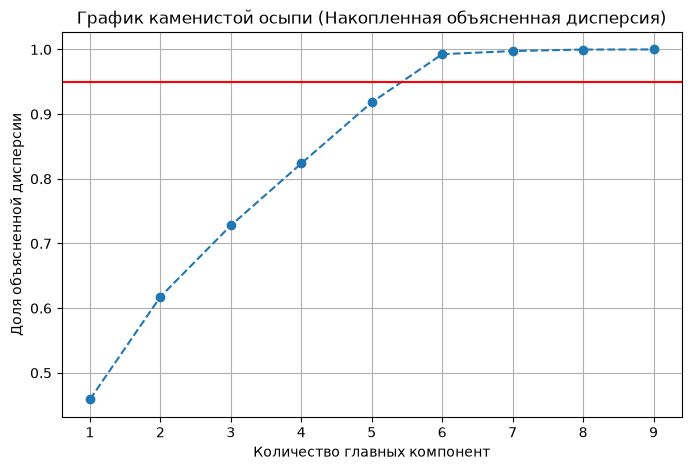

In [67]:
pca = PCA()
pca.fit(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('График каменистой осыпи (Накопленная объясненная дисперсия)')
plt.xlabel('Количество главных компонент')
plt.ylabel('Доля объясненной дисперсии')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid(True)
plt.show()

Анализ графика каменистой осыпи показал, что выбор главных компонент, покрывающих $\ge 95\%$ суммарной дисперсии данных, позволяет существенно снизить размерность пространства признаков и устранить мультиколлинеарность.

In [68]:
pca_optimal = PCA(n_components=0.95)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)

print(f"Количество признаков после PCA: {X_train_pca.shape[1]}")

results_after_pca = []

for name, model in models.items():
    res = evaluate_model(model, X_train_pca, X_test_pca, y_train, y_test, name + " (PCA)")
    results_after_pca.append(res)

df_results_after = pd.DataFrame(results_after_pca)
print("Результаты моделей ПОСЛЕ применения PCA:")
display(df_results_after)

Количество признаков после PCA: 6
Результаты моделей ПОСЛЕ применения PCA:


,Model,RMSE,R²,MAPE
0,Linear Regression (PCA),1666.285106,0.826814,0.636557
1,Ridge Regression (PCA),1666.284754,0.826814,0.636544
2,Lasso Regression (PCA),1666.284592,0.826814,0.636511


,Model,RMSE,R²,MAPE
0,Linear Regression,1331.040316,0.889491,0.376800
1,Ridge Regression,1331.021537,0.889495,0.376854
2,Lasso Regression,1329.287997,0.889782,0.376798
3,Linear Regression (PCA),1666.285106,0.826814,0.636557
4,Ridge Regression (PCA),1666.284754,0.826814,0.636544
5,Lasso Regression (PCA),1666.284592,0.826814,0.636511


C:\Users\админ\AppData\Local\Temp\ipykernel_34076\1976388780.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x='Model', y='R²', palette='Set2')


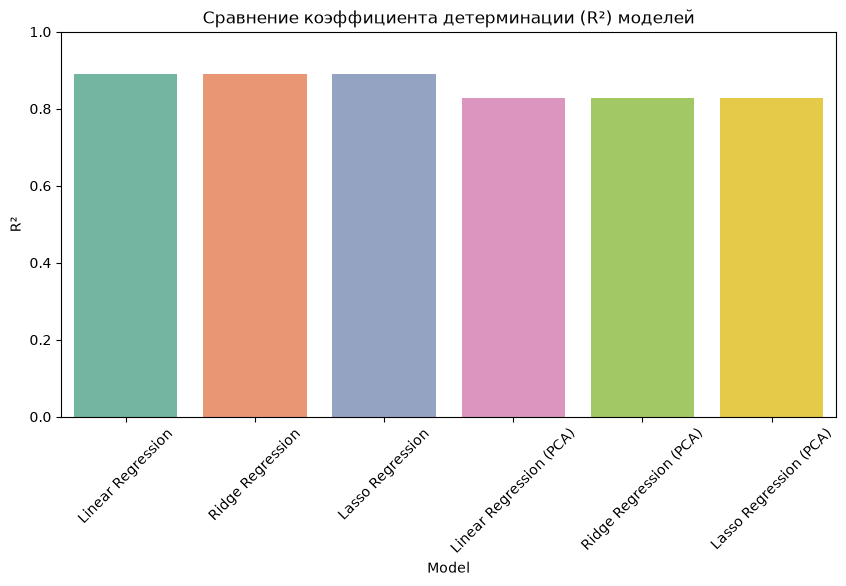

In [69]:
df_comparison = pd.concat([df_results_before, df_results_after]).reset_index(drop=True)
display(df_comparison)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_comparison, x='Model', y='R²', palette='Set2')
plt.xticks(rotation=45)
plt.title('Сравнение коэффициента детерминации (R²) моделей')
plt.ylim(0, 1)
plt.show()

Объясненная дисперсия каждой компонентой:
[0.65535644 0.21400867 0.11389973 0.0079     0.00663336 0.0022018 ]


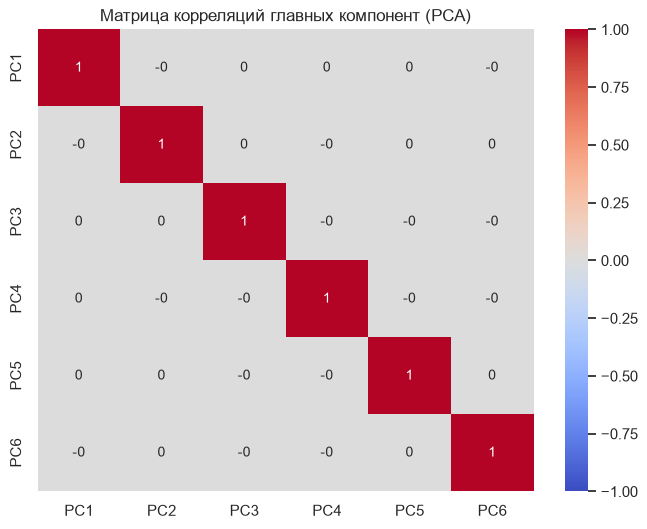

In [ ]:
X_num_scaled = StandardScaler().fit_transform(df[numeric_features])

pca = PCA(n_components=X_num_scaled.shape[1])
X_pca = pca.fit_transform(X_num_scaled)

print("Объясненная дисперсия каждой компонентой:")
print(pca.explained_variance_ratio_)

pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

plt.figure(figsize=(8, 6))
sns.heatmap(np.round(pca_df.corr(), 5), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций главных компонент (PCA)')
plt.show()

### Заключение 

1. Выявлена сильная корреляция целевой переменной `price` с весом `carat` и геометрическими размерами `x`, `y`, `z`. 
2. Расчет VIF подтвердил наличие сильной мультиколлинеарности между размерами и весом.
3. Исходные модели линейной, Ridge и Lasso регрессии показали высокое значение метрики R² (около 0.88 - 0.90), однако мультиколлинеарность может делать модели нестабильными.
4. Метод главных компонент позволил снизить размерность признакового пространства с 9 до меньшего количества компонент, сохранив при этом 95% дисперсии. 
5. Модели, обученные на главных компонентах, показали метрики немного ниже, чем исходные (что естественно при потере части информации), однако позволили полностью избавиться от проблемы мультиколлинеарности и ускорить процесс вычислений. Снижение метрик говорит о том, что для максимизации предсказательной точности в данном конкретном случае можно использовать регуляризацию без сильного сжатия размерности, либо использовать более сложные нелинейные модели.

### Список литературы 